In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import get_standard_evaluations
from biked_commons.resource_utils import split_datasets_path
from biked_commons.conditioning import conditioning

from biked_commons.design_evaluation.scoring import *
from biked_commons.benchmark_models import benchmarking_utils

c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)

device = "cpu"

In [3]:
def get_condition(idx=0):
    rider_condition = conditioning.sample_riders(10, split="test")
    use_case_condition = conditioning.sample_use_case(10, split="test")
    image_embeddings = conditioning.sample_image_embedding(10, split="test")
    condition = {"Rider": rider_condition[idx], "Use Case": use_case_condition[idx], "Embedding": image_embeddings[idx]}
    return condition


In [4]:
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
class BikeBenchProblem(Problem):
    def __init__(self, data_sample_df, conditioning):
        evaluator, requirement_names, requirement_types = construct_tensor_evaluator(get_standard_evaluations("cpu"), data_sample_df.columns)
        data_sample = data_sample_df.to_numpy()
        
        self.conditioning = conditioning

        self.evaluator=evaluator
        self.requirement_names=requirement_names
        isobjective = torch.tensor(requirement_types) == 1
        self.isobjective = isobjective

        n_var = data_sample.shape[1]
        n_obj = torch.sum(isobjective)
        n_ieq_constr = torch.sum(~isobjective)
        xl = np.quantile(data_sample, 0.01, axis=0)
        xu = np.quantile(data_sample, 0.99, axis=0)
        super().__init__(n_var=n_var, n_obj=n_obj, n_ieq_constr=n_ieq_constr, xl=xl, xu=xu)

    def evaluate_fn(self, X):
        X_tens = torch.tensor(X, dtype=torch.float32)
        eval_scores = self.evaluator(X_tens, self.conditioning)
        objective_scores = eval_scores[:, self.isobjective].detach().numpy()
        constraint_scores = eval_scores[:, ~self.isobjective].detach().numpy()
        return objective_scores, constraint_scores

    def _evaluate(self, x, out, *args, **kwargs):
        objective_scores, constraint_scores = self.evaluate_fn(x)
        out["F"] = objective_scores
        out["G"] = constraint_scores

In [ ]:
for i in range(1):
    condition = get_condition(i)
    problem = BikeBenchProblem(data, condition)

    algorithm = NSGA2(pop_size=100)

    res = minimize(problem, algorithm, ('n_gen', 1000), seed=1, verbose=False)

    results_tens = torch.tensor(res.X, dtype=torch.float32)
    benchmarking_utils.evaluate_uncond(results_tens, "NSGA2", i, data.columns, device="cpu")

In [6]:
result_tens = torch.tensor(res.X, dtype=torch.float32)

In [7]:
main_scorer = construct_scorer(MainScores, StandardEvaluations, data.columns)
detailed_scorer = construct_scorer(DetailedScores, StandardEvaluations, data.columns)

NameError: name 'StandardEvaluations' is not defined

In [ ]:
main_scorer(result_tens, condition)

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Hypervolume                     0.219089
Constraint Satisfaction Rate    1.000000
Maximum Mean Discrepancy        1.036764
dtype: float64

In [ ]:
detailed_scorer(result_tens, condition)

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Min Objective Score: Usability Score - 0 to 1                                                                0.101918
Min Objective Score: Drag Force                                                                             10.090542
Min Objective Score: Knee Angle Error                                                                       31.159355
Min Objective Score: Hip Angle Error                                                                        21.689135
Min Objective Score: Arm Angle Error                                                                         0.000000
Min Objective Score: Mass                                                                                    6.525248
Min Objective Score: Planar Compliance                                                                       0.000000
Min Objective Score: Transverse Compliance                                                                   0.960608
Min Objective Score: Eccentric Compliance               

In [ ]:
result_df = pd.DataFrame(result_tens.numpy(), columns=data.columns)

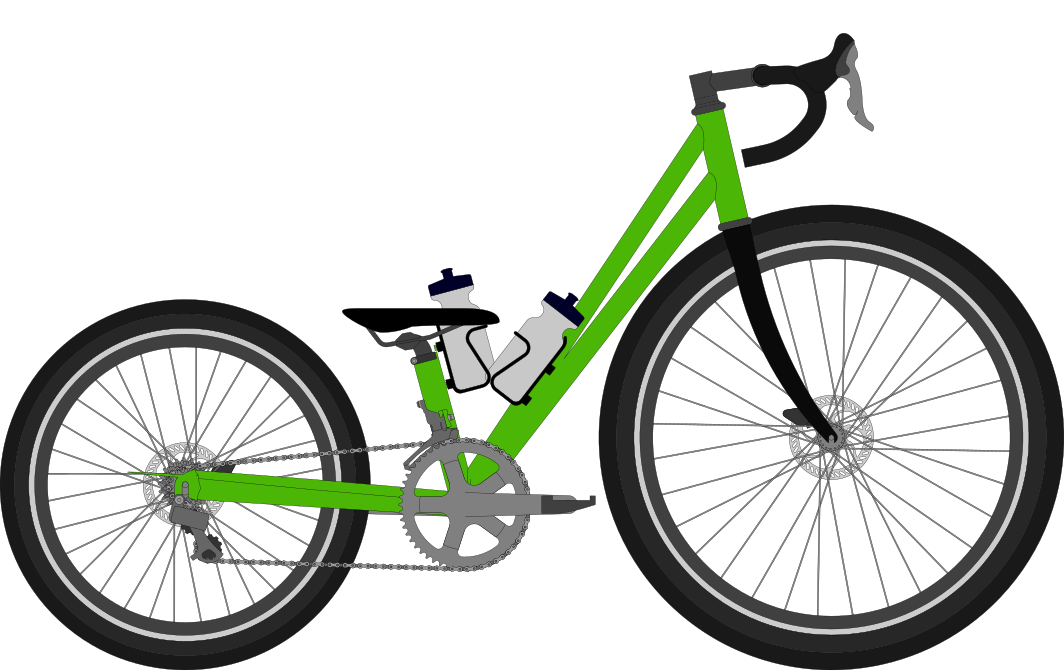

In [ ]:
from biked_commons.api import rendering
renderer = rendering.RenderingEngine(number_rendering_servers = 1, server_init_timeout_seconds=120)

res1 = result_df.iloc[0]
res = renderer.render_clip(res1)
svg = res.image_bytes
from IPython.display import SVG, display
display(SVG(svg))